# **SALES PERFORMANCE & CUSTOMER BEHAVIOR ANALYSIS**
##### **by Lucila Aldana Quiñonez | Marketing Data Analyst**

In [2]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from IPython.display import display

In [3]:
# Import the dataset
sales_df = pd.read_csv(r"C:\Users\lucil\Documents\Education\Data Analysis\Python\Projects Python\Sales Performance & Customer Behavior Analysis - by Lucila Aldana Quiñonez _ Marketing Data Analyst\ecommerce_sales_dataraw.csv")

# General overview of the data
sales_df.info()

# Dataset preview
sales_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Missing values found in the "Postal Code" column 
null_count = sales_df['Postal Code'].isnull().sum()
print(null_count)

11


# **DATA CLEANING**

In [5]:
## Correct column’s data type

# Fix the "Postal Code" column data type from float64 to string
sales_df["Postal Code"] = sales_df["Postal Code"].astype("string")

# Fix the "Order Date" column data type from object to datetime
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"], format="%d/%m/%Y")

# Fix the "Ship Date" column data type from object to datetime
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"], format="%d/%m/%Y")

# Checking if data type changes worked correctly
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   string        
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [6]:
# Check for duplicates
if sales_df.duplicated().sum() > 0:
    print('Duplicates are present')
else:
    print('No duplicates exist')

# Another way to check for duplicates 
# sales_df.duplicated(keep=False).sum()

No duplicates exist


## **Save Clean Dataset**

In [13]:
sales_df.to_csv("ecommerce_sales_data_cleandata.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# **EXPLORATORY DATA ANALYSIS**
## **Sales Trends**

## <u>Sales Trends Over Time by Revenue</u>

Monthly sales trend across the entire dataset period:


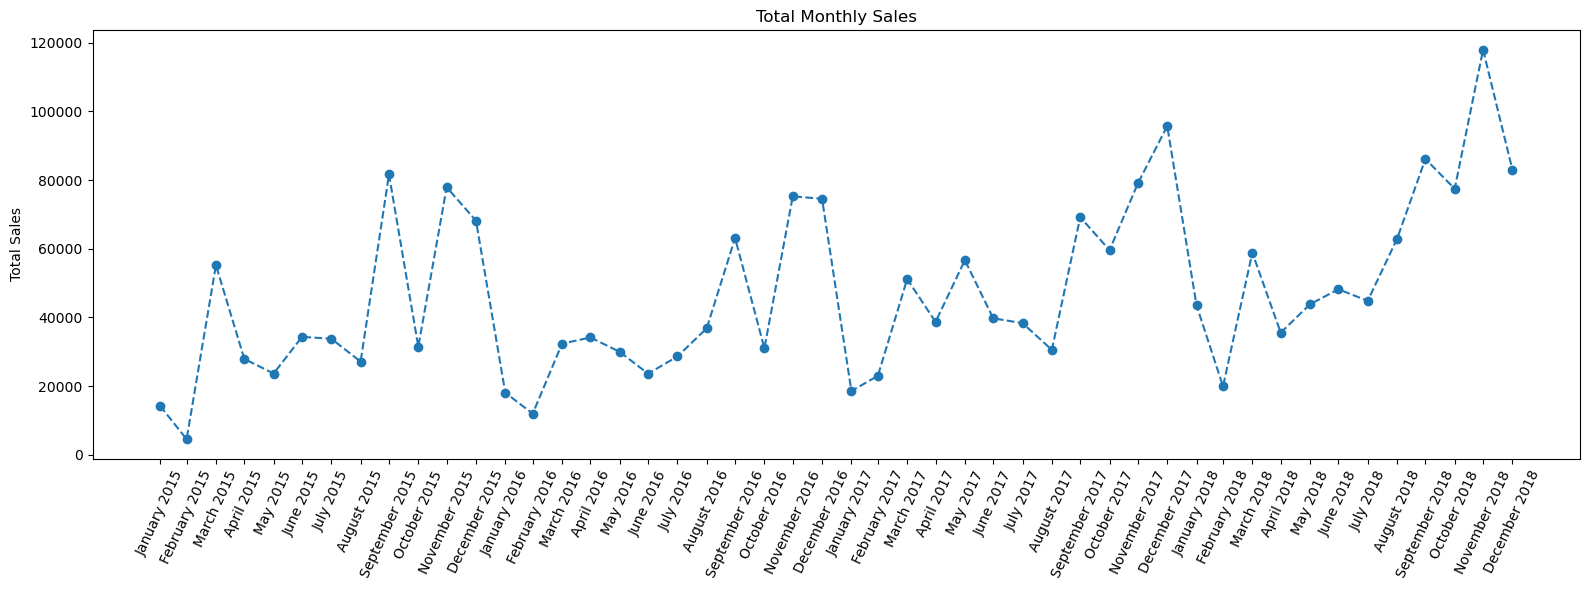

In [309]:
# Group sales per month for the entire period
all_monthly_sales = (
    sales_df
        .resample('ME', on='Order Date')['Sales']
        .sum()
        .reset_index()
        .rename(columns={
            'Order Date': 'Year_Month',
            'Sales': 'Total_Sales'
        })
)

# Visualize all monthly sales with a line chart
plt.figure(figsize=(16, 6))  # Wider chart

plt.plot(
    all_monthly_sales['Year_Month'],
    all_monthly_sales['Total_Sales'],
    marker='o',
    linestyle='--'
)

# Titles and labels
plt.title('Total Monthly Sales')
plt.ylabel('Total Sales')

# Format x-axis labels
formatted_labels = all_monthly_sales['Year_Month'].dt.strftime('%B %Y')

# Force all months to appear on x-axis
plt.xticks(
    ticks=all_monthly_sales['Year_Month'],
    labels=formatted_labels,
    rotation=65
)

plt.tight_layout()  # Prevent label cutoff

print('Monthly sales trend across the entire dataset period:')
#plt.savefig("all_monthly_sales.jpg", dpi=300) # Saving the image as a .jpg file
plt.show()

In [7]:
# Analyzing sales for specific months in a specific year
total_sales = sales_df.loc[
    (sales_df['Order Date'].dt.year == 2015) &
    (sales_df['Order Date'].dt.month.isin([1, 2, 3, 4, 5, 6, 7, 8])),   # [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
    'Sales'
].sum()

print(total_sales)

220704.5691


## Revenue by Year:

These are the yearly sales across the entire dataset period:
   Year  Total_Sales
0  2015  479856.2081
1  2016  459436.0054
2  2017  600192.5500
3  2018  722052.0192


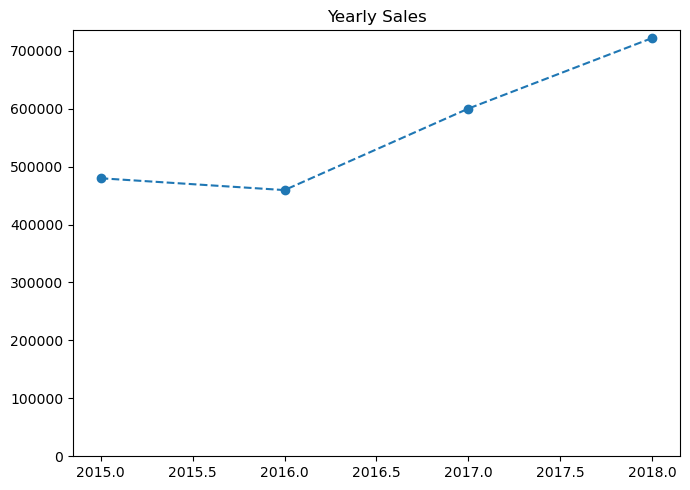

In [264]:
# Group sales per year
yearly_sales = (
    sales_df
        .groupby(sales_df['Order Date'].dt.year)['Sales']
        .sum()
        .reset_index()
        .rename(columns={'Order Date': 'Year', 'Sales': 'Total_Sales'})
)

# Visualize yearly sales with a line chart
plt.figure(figsize=(7, 5))

plt.plot(
    yearly_sales['Year'],
    yearly_sales['Total_Sales'],
    marker='o',
    linestyle='--'
)

# Titles and labels
plt.title('Yearly Sales')

plt.ylim(bottom=0) # Force y-axis to start at 0

plt.tight_layout()

print('These are the yearly sales across the entire dataset period:')
print(yearly_sales)

#plt.savefig("yearly_sales.jpg", dpi=300) # Saving the image as a .jpg file
plt.show()

## Revenue by Quarter:

These are the quarterly sales across the entire dataset period:


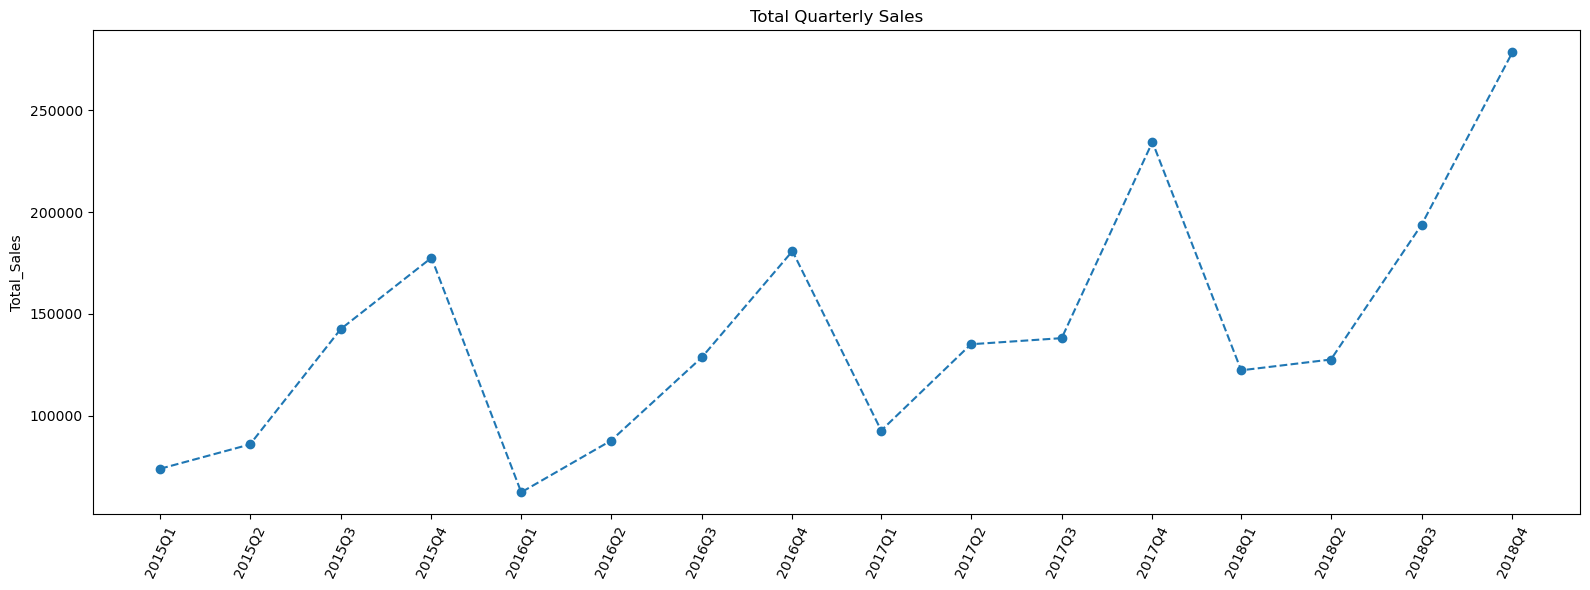

In [310]:
# Group sales per month for the entire period
quarterly_sales = (
    sales_df
        .resample('QE', on='Order Date')['Sales']
        .sum()
        .reset_index()
        .rename(columns={
            'Order Date': 'Year_Quarter',
            'Sales': 'Total_Sales'
        })
)

# Visualize all monthly sales with a line chart
plt.figure(figsize=(16, 6))  # Wider chart

plt.plot(
    quarterly_sales['Year_Quarter'],
    quarterly_sales['Total_Sales'],
    marker='o',
    linestyle='--'
)

# Titles and labels
plt.title('Total Quarterly Sales')
plt.ylabel('Total_Sales')

# Format x-axis labels
formatted_labels = quarterly_sales['Year_Quarter'].dt.to_period('Q').astype(str)

# Force all quarters to appear on x-axis
plt.xticks(
    ticks=quarterly_sales['Year_Quarter'],
    labels=formatted_labels,
    rotation=65
)

plt.tight_layout()  # Prevent label cutoff

print('These are the quarterly sales across the entire dataset period:')
plt.show()

## Revenue by Month and Single Year:

These are the monthly sales across the year 2015:


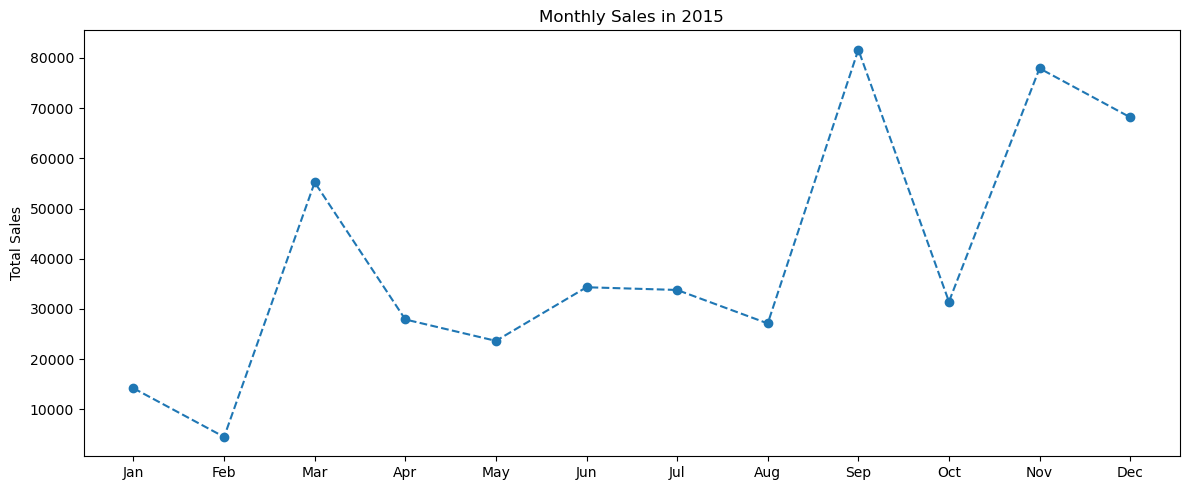

In [311]:
# Select single year
year = 2015

# Calculate monthly sales for a single year
sales_single_year = (
    sales_df[
        sales_df['Order Date'].dt.year == year
    ]
    .groupby(sales_df['Order Date'].dt.month)['Sales']
    .sum()
    .reset_index()
    .rename(columns={
        'Order Date': 'Month',
        'Sales': 'Total_Sales'
    })
)

# Visualize the monthly sales of a single year with a line chart
plt.figure(figsize=(12, 5))

plt.plot(
    sales_single_year['Month'],
    sales_single_year['Total_Sales'],
    marker='o',
    linestyle='--'
)

# Titles and labels
plt.title(f'Monthly Sales in {year}')
plt.ylabel('Total Sales')

plt.xticks(
    ticks=range(1, 13),
    labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ]
)

plt.tight_layout()  # Prevent label cutoff

print(f'These are the monthly sales across the year {year}:')
#plt.savefig("sales_single_year.jpg", dpi=300) # Saving the image as a .jpg file
plt.show()

## Revenue Metrics Analysis:

In [338]:
orders_df = (
    sales_df
    .groupby('Order ID', as_index=False)['Sales']
    .sum()
    .rename(columns={'Sales': 'Order Total'})
    .sort_values(by='Order Total', ascending=False)
)

quanitles_df = orders_df['Order Total'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

print(orders_df)
print('Percentiles:')
print(quanitles_df)

            Order ID  Order Total
533   CA-2015-145317    23661.228
1956  CA-2017-118689    18336.740
3538  CA-2018-140151    14052.480
3296  CA-2018-127180    13716.458
473   CA-2015-139892    10539.896
...              ...          ...
4637  US-2018-100209        1.080
4240  US-2015-152723        0.876
158   CA-2015-112403        0.852
2723  CA-2017-168361        0.836
3238  CA-2018-124114        0.556

[4922 rows x 2 columns]
Percentiles:
0.50     151.87500
0.75     513.51400
0.90    1158.41520
0.95    1800.15810
0.99    4206.35676
Name: Order Total, dtype: float64


## <u>Sales Trends Over Time by Order Volume</u>

In [267]:
sales_count = sales_df['Order ID'].nunique()

print(f'The total number of sales across the entire dataset period is {sales_count}.')

The total number of sales across the entire dataset period is 4922.


These are the monthly order volumes across the entire dataset period:


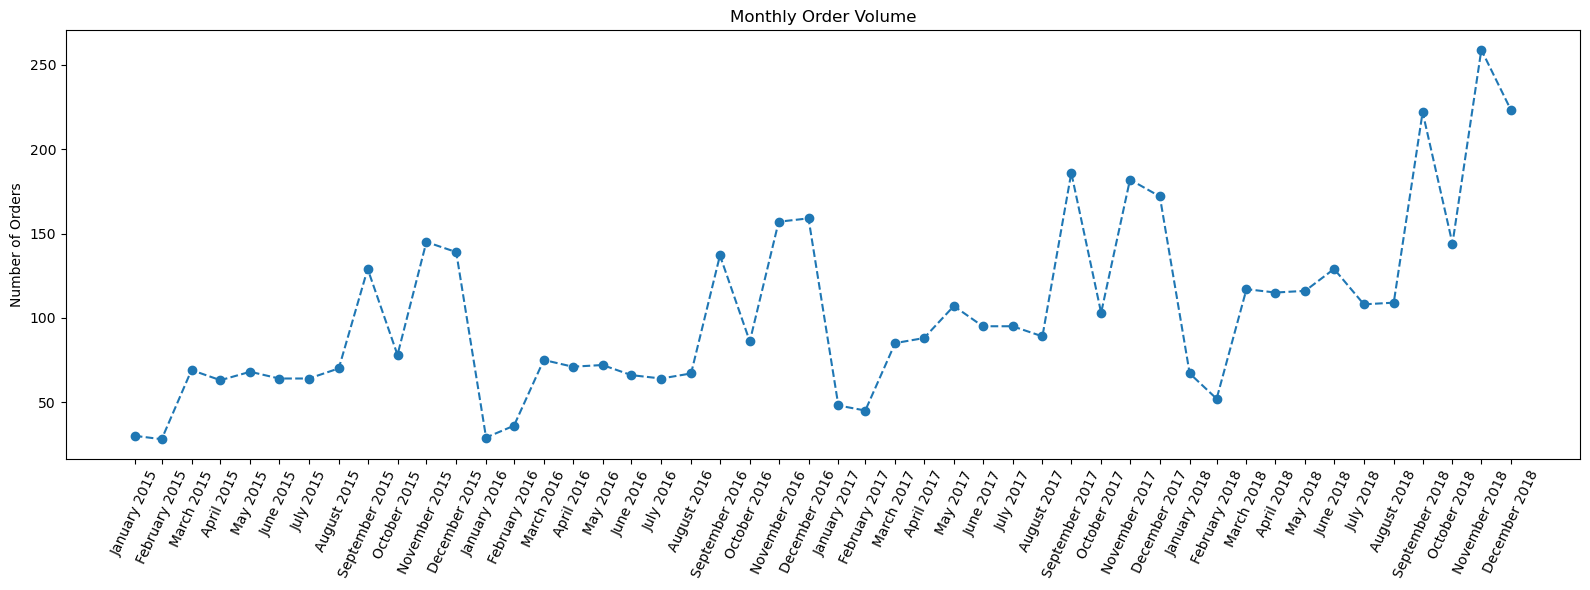

In [312]:
# Monthly order volume
all_monthly_order_volume = (
    sales_df
        [['Order ID', 'Order Date']]
        .drop_duplicates()
        .resample('ME', on='Order Date')
        .size()
        .reset_index(name='Order_Volume')
        .rename(columns={'Order Date': 'Year_Month'})
)

# Visualize the monthly order volume
plt.figure(figsize=(16, 6))

plt.plot(
    all_monthly_order_volume['Year_Month'],
    all_monthly_order_volume['Order_Volume'],
    marker='o',
    linestyle='--'
)

plt.title('Monthly Order Volume')
plt.ylabel('Number of Orders')

formatted_labels = all_monthly_order_volume['Year_Month'].dt.strftime('%B %Y')

plt.xticks(
    ticks=all_monthly_order_volume['Year_Month'],
    labels=formatted_labels,
    rotation=65
)

plt.tight_layout()

print('These are the monthly order volumes across the entire dataset period:')
#plt.savefig("all_monthly_order_volume.jpg", dpi=300) # Saving the image as a .jpg file
plt.show()

## Sales Order Volume by Year:

These are the yearly order volumes across the entire dataset period:
   Year  Order_Volume
0  2015           947
1  2016          1019
2  2017          1295
3  2018          1661


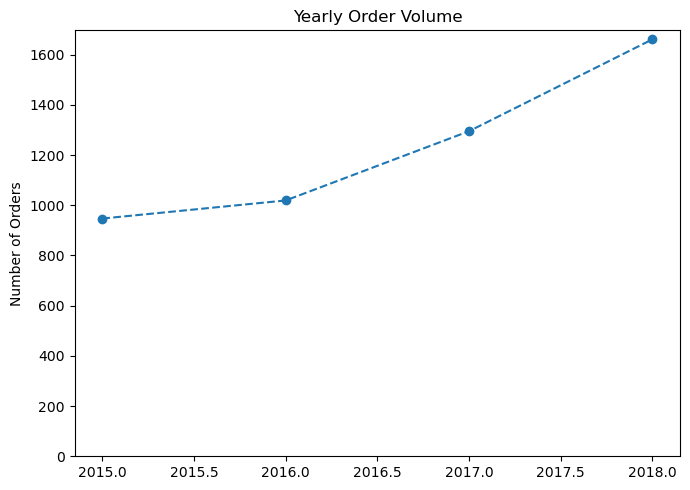

In [269]:
# Yearly order volume
yearly_order_volume = (
    sales_df
        [['Order ID', 'Order Date']]
        .drop_duplicates()
        .assign(Year=lambda x: x['Order Date'].dt.year)
        .groupby('Year')
        .size()
        .reset_index(name='Order_Volume')
)

# Visualize the yearly order volume
plt.figure(figsize=(7, 5))

plt.plot(
    yearly_order_volume['Year'],
    yearly_order_volume['Order_Volume'],
    marker='o',
    linestyle='--'
)

plt.title('Yearly Order Volume')
plt.ylabel('Number of Orders')

plt.ylim(bottom=0)
plt.tight_layout()

print('These are the yearly order volumes across the entire dataset period:')
print(yearly_order_volume)
plt.show()

## Sales Order Volume by Quarter:

These are the quarterly order volumes across the entire dataset period:


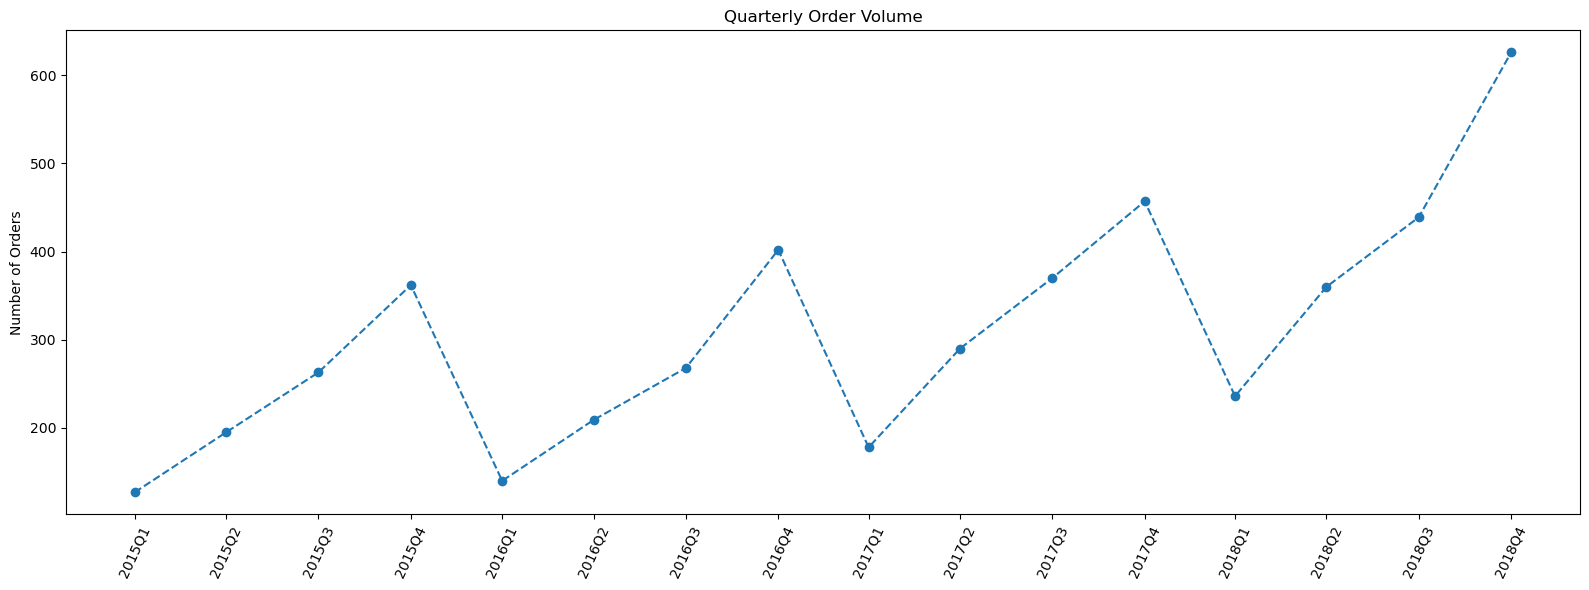

In [313]:
quarterly_order_volume = (
    sales_df
        [['Order ID', 'Order Date']]
        .drop_duplicates()
        .resample('QE', on='Order Date')
        .size()
        .reset_index(name='Order_Volume')
        .rename(columns={'Order Date': 'Year_Quarter'})
)

# Visualize
plt.figure(figsize=(16, 6))

plt.plot(
    quarterly_order_volume['Year_Quarter'],
    quarterly_order_volume['Order_Volume'],
    marker='o',
    linestyle='--'
)

plt.title('Quarterly Order Volume')
plt.ylabel('Number of Orders')

formatted_labels = quarterly_order_volume['Year_Quarter'].dt.to_period('Q').astype(str)

plt.xticks(
    ticks=quarterly_order_volume['Year_Quarter'],
    labels=formatted_labels,
    rotation=65
)

plt.tight_layout()

print('These are the quarterly order volumes across the entire dataset period:')
plt.show()

## Sales Order Volume by Month and Single Year

These are the monthly order volumes across the year 2015:


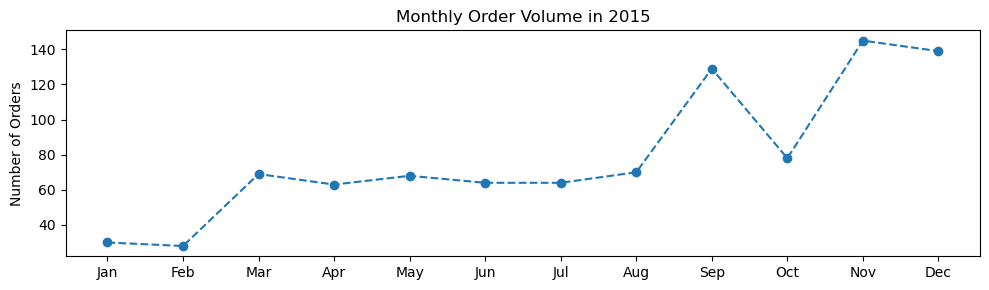

In [375]:
# Select single year
year = 2015

# Monthly order volume for a single year (order-level)
monthly_order_volume_single_year = (
    sales_df[
        sales_df['Order Date'].dt.year == year
    ]
    [['Order ID', 'Order Date']]
    .drop_duplicates()
    .groupby(sales_df['Order Date'].dt.month)
    .size()
    .reset_index(name='Order_Volume')
    .rename(columns={'Order Date': 'Month'})
)

# Visualize
plt.figure(figsize=(10, 3))

plt.plot(
    monthly_order_volume_single_year['Month'],
    monthly_order_volume_single_year['Order_Volume'],
    marker='o',
    linestyle='--'
)

plt.title(f'Monthly Order Volume in {year}')
plt.ylabel('Number of Orders')

plt.xticks(
    ticks=range(1, 13),
    labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ]
)

plt.tight_layout()

print(f'These are the monthly order volumes across the year {year}:')
plt.show()

## Average Number of Orders in Specific Months in a Specific Year:

In [350]:
year = 2015
months = [, 10, 11, 12]   # [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

df_filtered = sales_df.loc[
    (sales_df['Order Date'].dt.year == year) &
    (sales_df['Order Date'].dt.month.isin(months)),
    ['Order Date', 'Order ID']
]

monthly_orders = (
    df_filtered
    .groupby(df_filtered['Order Date'].dt.month)['Order ID']
    .nunique()
    .reindex(months, fill_value=0)
)

average_orders_per_month = monthly_orders.mean()

print(f'Average orders per month ({year}, months {months}): {average_orders_per_month:.2f}')

Average orders per month (2015, months [12]): 139.00


## <u>Geographical Analysis<u/>

## Sales Revenue Percentage by Region, State and City:

In [363]:
# Sales percentage by Region
sales_by_region = (
    sales_df
    .groupby('Region', as_index=False)['Sales']
    .sum()
)

# Calculate total sales
total_sales = sales_by_region['Sales'].sum()

# Convert to percentage
sales_by_region['Sales %'] = (sales_by_region['Sales'] / total_sales) * 100

# Sort by percentage descending
sales_by_region = sales_by_region.sort_values(by='Sales %', ascending=False)

# Optional: keep only the percentage column
sales_by_region = sales_by_region[['Region', 'Sales %']]

# Rounding percentages to two decimal points
sales_by_region['Sales %'] = sales_by_region['Sales %'].round(2)

print('Sales Percentage by Region:')
print(sales_by_region.reset_index(drop=True))

Sales Percentage by Region:
    Region  Sales %
0     West    31.40
1     East    29.60
2  Central    21.78
3    South    17.21


In [387]:
# Sales percentage by State
sales_by_state = (
    sales_df
    .groupby('State', as_index=False)['Sales']
    .sum()
)

# Calculate total sales
total_sales = sales_by_state['Sales'].sum()

# Convert to percentage
sales_by_state['Sales %'] = (sales_by_state['Sales'] / total_sales) * 100

# Sort by percentage descending
sales_by_state = sales_by_state.sort_values(by='Sales %', ascending=False)

# Keep relevant columns
sales_by_state = sales_by_state[['State', 'Sales %']]

# Rounding percentages to two decimal points
sales_by_state['Sales %'] = sales_by_state['Sales %'].round(2)

print('Sales Percentage by State:')
print(sales_by_state.reset_index(drop=True).head(5))

Sales Percentage by State:
           State  Sales %
0   North Dakota     0.04
1  West Virginia     0.05
2          Maine     0.06
3   South Dakota     0.06
4        Wyoming     0.07


In [388]:
# Sales percentage by City
sales_by_city = (
    sales_df
    .groupby('City', as_index=False)['Sales']
    .sum()
)

# Calculate total sales
total_sales = sales_by_city['Sales'].sum()

# Convert to percentage
sales_by_city['Sales %'] = (sales_by_city['Sales'] / total_sales) * 100

# Sort by percentage descending
sales_by_city = sales_by_city.sort_values(by='Sales %', ascending=False)

# Keep relevant columns
sales_by_city = sales_by_city[['City', 'Sales %']]

# Rounding percentages to two decimal points
sales_by_city['Sales %'] = sales_by_city['Sales %'].round(2)

print('Sales Percentage by City:')
print(sales_by_city.reset_index(drop=True).head(7))

Sales Percentage by City:
              City  Sales %
0          Abilene      0.0
1           Elyria      0.0
2          Jupiter      0.0
3        Pensacola      0.0
4     Ormond Beach      0.0
5  San Luis Obispo      0.0
6       Springdale      0.0


## Sales Order Volume Percentage by Region, State and City:

In [377]:
# Sales Order Volume percentage by Region
orders_by_region = (
    sales_df[['Order ID', 'Region']]
    .drop_duplicates()
    .groupby('Region')
    .size()
    .reset_index(name='Order Volume')
)

# Calculate total number of orders
total_orders = orders_by_region['Order Volume'].sum()

# Convert to percentage
orders_by_region['Order %'] = (orders_by_region['Order Volume'] / total_orders) * 100

# Sort by percentage descending
orders_by_region = orders_by_region.sort_values(by='Order %', ascending=False)

# Keep relevant columns
orders_by_region = orders_by_region[['Region', 'Order %']]

# Rounding percentages to two decimal points
orders_by_region['Order %'] = orders_by_region['Order %'].round(2)

print('Sales Order Volume by Region (%):')
print(orders_by_region.reset_index(drop=True))

Sales Order Volume by Region (%):
    Region  Order %
0     West    32.24
1     East    27.81
2  Central    23.49
3    South    16.46


In [386]:
# Sales Order Volume by State
orders_by_state = (
    sales_df[['Order ID', 'State']]
    .drop_duplicates()
    .groupby('State')
    .size()
    .reset_index(name='Order Volume')
)

# Calculate total number of orders
total_orders = orders_by_state['Order Volume'].sum()

# Convert to percentage
orders_by_state['Order %'] = (orders_by_state['Order Volume'] / total_orders) * 100

# Sort by percentage descending
orders_by_state = orders_by_state.sort_values(by='Order %', ascending=False)

# Keep relevant columns
orders_by_state = orders_by_state[['State', 'Order %']]

# Rounding percentages to two decimal points
orders_by_state['Order %'] = orders_by_state['Order %'].round(2)

print('Sales Order Volume by State (%):')
print(orders_by_state.reset_index(drop=True).head(5))

Sales Order Volume by State (%):
          State  Order %
0    California    20.36
1      New York    11.11
2         Texas     9.75
3  Pennsylvania     5.79
4      Illinois     5.49


In [385]:
# Sales Order Volume by City
orders_by_city = (
    sales_df[['Order ID', 'City']]
    .drop_duplicates()
    .groupby('City')
    .size()
    .reset_index(name='Order Volume')
)

# Calculate total number of orders
total_orders = orders_by_city['Order Volume'].sum()

# Convert to percentage
orders_by_city['Order %'] = (orders_by_city['Order Volume'] / total_orders) * 100

# Sort by percentage descending
orders_by_city = orders_by_city.sort_values(by='Order %', ascending=False)

# Keep relevant columns
orders_by_city = orders_by_city[['City', 'Order %']]

# Rounding percentages to two decimal points
orders_by_city['Order %'] = orders_by_city['Order %'].round(2)

print('Sales Order Volume by City (%):')
print(orders_by_city.reset_index(drop=True).head(10))

Sales Order Volume by City (%):
            City  Order %
0  New York City     8.92
1    Los Angeles     7.68
2   Philadelphia     5.32
3  San Francisco     5.30
4        Seattle     4.27
5        Houston     3.78
6        Chicago     3.37
7       Columbus     2.23
8      San Diego     1.79
9         Dallas     1.61


# **Shipping Insights**

In [8]:
# Identify the shipping methods:
type_of_shipping = sales_df['Ship Mode'].unique()

print('This are the shipping methods used by the company:')
print(type_of_shipping)

This are the shipping methods used by the company:
['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [7]:
# Check the number of shipping methods used for each order
shipping_methods_per_order = (
    sales_df
        .groupby('Order ID')['Ship Mode']
        .nunique()
)

# Orders with more than one shipping method
orders_with_multiple_shipping = shipping_methods_per_order[
    shipping_methods_per_order > 1
]

print(f'Orders with more than one shipping method: {len(orders_with_multiple_shipping)}')

# Check number of problematic orders, if any
## sales_df[
##     sales_df['Order ID'].isin(orders_with_multiple_shipping.index)
## ].sort_values('Order ID')

Orders with more than one shipping method: 0


## <u>Shipping Methods Share<u/>

#### Since the dataset contains multiple rows per order, shipping method usage was calculated at the order level by deduplicating Order IDs to avoid inflated counts.

Shipping method usage across the entire dataset period:
        Ship Mode  Order_Count
3  Standard Class         2945
2    Second Class          944
0     First Class          772
1        Same Day          261


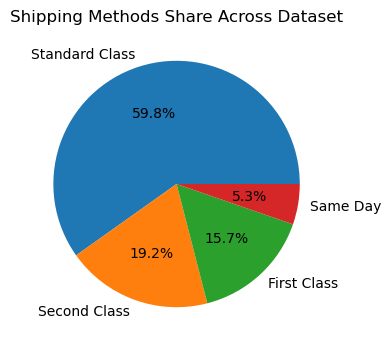

In [14]:
# Frequency use of shipping methods
shipping_freq_use = (
    sales_df
        [['Order ID', 'Ship Mode']]
        .drop_duplicates()
        .groupby('Ship Mode')
        .size()
        .reset_index(name='Order_Count')
        .sort_values('Order_Count', ascending=False)
)

# Visualize the shipping methods share with a pie chart
plt.figure(figsize=(5,4))

plt.pie(shipping_freq_use['Order_Count'], labels = shipping_freq_use['Ship Mode'], autopct = '%1.1f%%')

# Setting the pie chart labels
plt.title('Shipping Methods Share Across Dataset')

print('Shipping method usage across the entire dataset period:')
print(shipping_freq_use)
#plt.savefig("shipping_methods_share.jpg", dpi=300)
plt.show()

Shipping method usage across the year 2018:
        Ship Mode  Order_Count
3  Standard Class          975
2    Second Class          318
0     First Class          280
1        Same Day           88


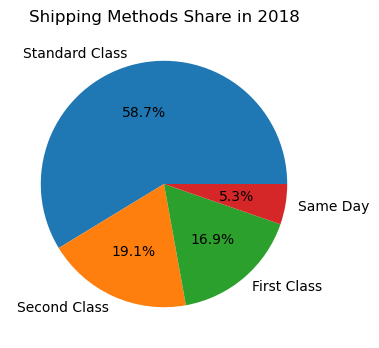

In [15]:
# Select single year
year = 2018

shipping_freq_use_single_year = (
    sales_df[
        sales_df['Order Date'].dt.year == year
    ]
    [['Order ID', 'Ship Mode']]
    .drop_duplicates()
    .groupby('Ship Mode')
    .size()
    .reset_index(name='Order_Count')
    .sort_values('Order_Count', ascending=False)
)

# Visualize the shipping methods share with a pie chart
plt.figure(figsize=(5,4))

plt.pie(
    shipping_freq_use_single_year['Order_Count'], 
    labels = shipping_freq_use_single_year['Ship Mode'], 
    autopct = '%1.1f%%'
)

# Setting the pie chart labels
plt.title(f'Shipping Methods Share in {year}')

print(f'Shipping method usage across the year {year}:')
print(shipping_freq_use_single_year)
plt.show()

In [20]:
# Select year and month
selected_year = 2018
selected_month = 6

sales_df["Year"] = sales_df["Order Date"].dt.year
sales_df["Month"] = sales_df["Order Date"].dt.month

filtered_df = sales_df[
    (sales_df["Year"] == selected_year) &
    (sales_df["Month"] == selected_month)
]

ship_mode_counts = (
    filtered_df["Ship Mode"]
    .value_counts()
    .reset_index()
)

ship_mode_counts.columns = ["Ship Mode", "Orders"]

total_orders = ship_mode_counts["Orders"].sum()

ship_mode_counts["Share %"] = (
    ship_mode_counts["Orders"] / total_orders * 100
).round(2)

ship_mode_counts = ship_mode_counts.sort_values(
    by="Share %",
    ascending=False
)

print(f"\nShip Mode Share — {selected_month}/{selected_year}\n")
print(ship_mode_counts)



Ship Mode Share — 6/2018

        Ship Mode  Orders  Share %
0  Standard Class     139    59.15
1     First Class      45    19.15
2    Second Class      45    19.15
3        Same Day       6     2.55


## <u>Shipping Methods Usage by Region and State<u/>

In [27]:
# Shipping methods usage by region
orders_region_shipping = (
    sales_df
        [['Order ID', 'Region', 'Ship Mode']]
        .drop_duplicates()
)

shipping_freq_by_region = (
    orders_region_shipping
        .groupby(['Region', 'Ship Mode'])
        .size()
        .reset_index(name='Order_Count')
        .sort_values(['Region', 'Order_Count'], ascending=[True, False])
)

print('Shipping method usage by region:')
print(shipping_freq_by_region)

Shipping method usage by region:
     Region       Ship Mode  Order_Count
3   Central  Standard Class          706
2   Central    Second Class          218
0   Central     First Class          171
1   Central        Same Day           61
7      East  Standard Class          810
6      East    Second Class          262
4      East     First Class          224
5      East        Same Day           73
11    South  Standard Class          488
10    South    Second Class          160
8     South     First Class          123
9     South        Same Day           39
15     West  Standard Class          941
14     West    Second Class          304
12     West     First Class          254
13     West        Same Day           88


In [6]:
# Shipping methods usage by state (dynamic)
orders_state_shipping = (
    sales_df
        [['Order ID', 'State', 'Ship Mode']]
        .drop_duplicates()
)

def shipping_methods_by_state(state_name):
    state_data = (
        orders_state_shipping
            .loc[orders_state_shipping['State'].str.lower() == state_name.lower()]
            .groupby('Ship Mode')
            .size()
            .reset_index(name='Order_Count')
            .sort_values('Order_Count', ascending=False)
    ) 
    if state_data.empty:
        print(f"No data found for state: {state_name}")
        return
    
    print(f"Shipping method usage in {state_name}:")
    print(state_data)
    

state_selected = input("Enter a state name (e.g., California): ")
shipping_methods_by_state(state_selected)

Enter a state name (e.g., California):  California


Shipping method usage in California:
        Ship Mode  Order_Count
3  Standard Class          589
2    Second Class          197
0     First Class          162
1        Same Day           54


## <u>Shipping Methods Contribution to Sales<u/>

#### Since sales values are additive, total revenue by shipping method was calculated by summing line-item sales. Unlike shipping method usage frequency, this metric is not affected by multiple rows per order.

These are the total sales contribution by shipping method:
        Ship Mode   Total_Sales
3  Standard Class  1.340831e+06
2    Second Class  4.499142e+05
0     First Class  3.455723e+05
1        Same Day  1.252190e+05


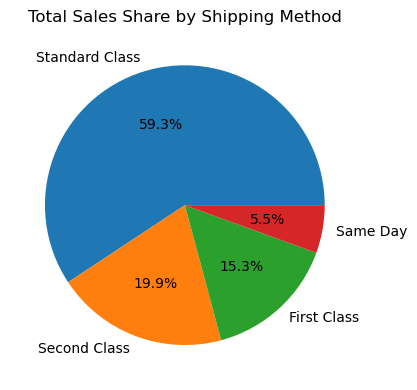

In [16]:
# Calculate the total sales by shipping method
sales_by_shipping_method = (
    sales_df
        .groupby('Ship Mode')['Sales']
        .sum()
        .reset_index()
        .rename(columns={'Sales': 'Total_Sales'})
        .sort_values('Total_Sales', ascending=False)
)

# Visualize the total sales share by shipping method
plt.figure(figsize=(5,4))

plt.pie(
    sales_by_shipping_method['Total_Sales'],
    labels=sales_by_shipping_method['Ship Mode'],
    autopct='%1.1f%%'
)

plt.title('Total Sales Share by Shipping Method')
plt.tight_layout()

print('These are the total sales contribution by shipping method:')
print(sales_by_shipping_method)
#plt.savefig("sales_share_by_shipping_methods.jpg", dpi=300)
plt.show()

These are the total sales contribution by shipping method across the year 2018:
        Ship Mode  Total_Sales
3  Standard Class  391531.8612
2    Second Class  142934.5754
0     First Class  139119.3306
1        Same Day   48466.2520


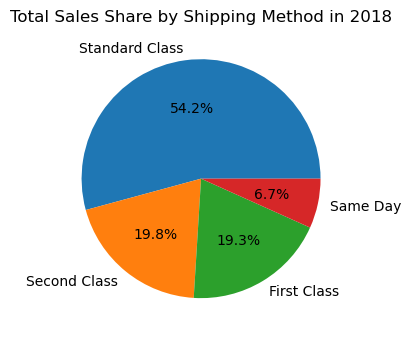

In [19]:
# Select single year
year = 2018

sales_by_shipping_method_year = (
    sales_df[
        sales_df['Order Date'].dt.year == year
    ]
    .groupby('Ship Mode')['Sales']
    .sum()
    .reset_index()
    .rename(columns={'Sales': 'Total_Sales'})
    .sort_values('Total_Sales', ascending=False)
)

# Visualize the total sales by shipping method by year
plt.figure(figsize=(4,4))

plt.pie(
    sales_by_shipping_method_year['Total_Sales'],
    labels=sales_by_shipping_method_year['Ship Mode'],
    autopct='%1.1f%%'
)

plt.title(f'Total Sales Share by Shipping Method in {year}')
plt.tight_layout()

print(f'These are the total sales contribution by shipping method across the year {year}:')
print(sales_by_shipping_method_year)

## <u>Shipping Methods Contribution to Orders<u/>

These are the order contribution by shipping method:
        Ship Mode  Total_Orders
3  Standard Class          2945
2    Second Class           944
0     First Class           772
1        Same Day           261


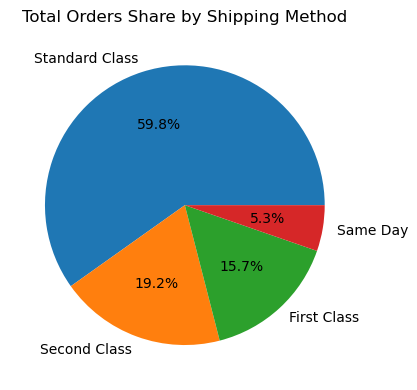

In [21]:
# Calculate the total orders by shipping method
orders_by_shipping_method = (
    sales_df
        .groupby('Ship Mode')['Order ID']
        .nunique()
        .reset_index()
        .rename(columns={'Order ID': 'Total_Orders'})
        .sort_values('Total_Orders', ascending=False)
)

# Visualize the total orders share by shipping method
plt.figure(figsize=(5,4))

plt.pie(
    orders_by_shipping_method['Total_Orders'],
    labels=sales_by_shipping_method['Ship Mode'],
    autopct='%1.1f%%'
)

plt.title('Total Orders Share by Shipping Method')
plt.tight_layout()

print('These are the order contribution by shipping method:')
print(orders_by_shipping_method)
#plt.savefig("orders_share_by_shipping_methods.jpg", dpi=300)
plt.show()

## <u>Shipping Efficiency<u/>

In [16]:
order_level_shipping_days = (
    sales_df
        [['Order ID', 'Ship Mode', 'Order Date', 'Ship Date']]
        .drop_duplicates()
)

order_level_shipping_days['Shipping_Days'] = (
    order_level_shipping_days['Ship Date'] -
    order_level_shipping_days['Order Date']
).dt.days

shipping_days_by_mode = (
    order_level_shipping_days
        .groupby('Ship Mode')['Shipping_Days']
        .agg(
            Min_Days='min',
            Max_Days='max',
            Avg_Days='mean'
        )
        .reset_index()
        .sort_values('Avg_Days')
)

print('Order-level shipping time statistics by Ship Mode:')
print(shipping_days_by_mode)

Order-level shipping time statistics by Ship Mode:
        Ship Mode  Min_Days  Max_Days  Avg_Days
1        Same Day         0         1  0.045977
0     First Class         1         4  2.185233
2    Second Class         1         5  3.237288
3  Standard Class         3         7  5.001358


In [17]:
# Shipping efficiency by region
order_level_shipping_days = (
    sales_df
        [['Order ID', 'Region', 'Ship Mode', 'Order Date', 'Ship Date']]
        .drop_duplicates()
)

# Calculate shipping days
order_level_shipping_days['Shipping_Days'] = (
    order_level_shipping_days['Ship Date'] -
    order_level_shipping_days['Order Date']
).dt.days

shipping_days_by_region = (
    order_level_shipping_days
        .groupby(['Region', 'Ship Mode'])['Shipping_Days']
        .agg(
            Min_Days='min',
            Max_Days='max',
            Avg_Days='mean'
        )
        .reset_index()
        .sort_values(['Region', 'Avg_Days'])
)

print('Order-level shipping time statistics by Region and Ship Mode:')
print(shipping_days_by_region)

Order-level shipping time statistics by Region and Ship Mode:
     Region       Ship Mode  Min_Days  Max_Days  Avg_Days
1   Central        Same Day         0         1  0.049180
0   Central     First Class         1         3  2.222222
2   Central    Second Class         2         5  3.380734
3   Central  Standard Class         3         7  4.983003
5      East        Same Day         0         0  0.000000
4      East     First Class         1         4  2.218750
6      East    Second Class         2         5  3.274809
7      East  Standard Class         4         7  4.982716
9     South        Same Day         0         1  0.025641
8     South     First Class         1         3  2.203252
10    South    Second Class         1         5  3.168750
11    South  Standard Class         4         7  5.004098
13     West        Same Day         0         1  0.090909
12     West     First Class         1         3  2.122047
14     West    Second Class         2         5  3.138158
15     Wes

In [23]:
# Shipping efficiency by state
order_level_shipping_days = (
    sales_df
        [['Order ID', 'State', 'Ship Mode', 'Order Date', 'Ship Date']]
        .drop_duplicates()
)

# Calculate shipping days
order_level_shipping_days['Shipping_Days'] = (
    order_level_shipping_days['Ship Date'] -
    order_level_shipping_days['Order Date']
).dt.days

def shipping_days_by_state(state_name):
    
    state_data = (
        order_level_shipping_days
            .loc[order_level_shipping_days['State'].str.lower() == state_name.lower()]
            .groupby('Ship Mode')['Shipping_Days']
            .agg(
                Min_Days='min',
                Max_Days='max',
                Avg_Days='mean'
            )
            .reset_index()
            .sort_values('Avg_Days')
    )
    
    if state_data.empty:
        print(f"No data found for state: {state_name}")
        return
    
    print(f"Order-level shipping time statistics in {state_name}:")
    print(state_data)

state_name = input("Enter a state name: ")
shipping_days_by_state(state_name)

Enter a state name:  Ohio


Order-level shipping time statistics in Ohio:
        Ship Mode  Min_Days  Max_Days  Avg_Days
1        Same Day         0         0  0.000000
0     First Class         1         4  2.302326
2    Second Class         2         5  3.060000
3  Standard Class         4         7  4.991304


# **Product Insights**

In [46]:
unique_products_count = sales_df['Product Name'].nunique()

print(f"Total unique products in the dataset: {unique_products_count}")

Total unique products in the dataset: 1849


## <u>Product Performance<u/>

In [36]:
# Top and bottom products ranking by orders

# Filters (set to None if you don't want to filter)
year = 2016
region = None
state = None
category = "Office Supplies" # Furniture, Office Supplies, Technology
sub_category = None

filtered_df = sales_df.copy()

if year is not None:
    filtered_df = filtered_df[
        filtered_df['Order Date'].dt.year == year
    ]

if region is not None:
    filtered_df = filtered_df[
        filtered_df['Region'] == region
    ]

if state is not None:
    filtered_df = filtered_df[
        filtered_df['State'] == state
    ]

if category is not None:
    filtered_df = filtered_df[
        filtered_df['Category'] == category
    ]

if sub_category is not None:
    filtered_df = filtered_df[
        filtered_df['Sub-Category'] == sub_category
    ]

top_products_by_orders = (
    filtered_df
        .groupby('Product Name')['Order ID']
        .nunique()
        .reset_index(name='Order_Count')
        .sort_values('Order_Count', ascending=False)   # True = bottom, False = top
        .head(20)
)

print('Top 20 products by number of orders:')
print(top_products_by_orders)

Top 20 products by number of orders:
                                          Product Name  Order_Count
225                                  Easy-staple paper           11
509                                    Staple envelope           11
513                                            Staples            9
73                                Aluminum Screw Posts            6
180  Boston Electric Pencil Sharpener, Model 1818, ...            5
2              #10- 4 1/8" x 9 1/2" Recycled Envelopes            5
127  Avery Heavy-Duty EZD View Binder with Locking ...            5
86                                           Avery 474            5
41                 Accohide Poly Flexible Ring Binders            4
271                   Fellowes Super Stor/Drawer Files            4
612                                         Xerox 1903            4
286   GBC Ibimaster 500 Manual ProClick Binding System            4
287                             GBC Imprintable Covers            4
665        

In [37]:
# Top and bottom products ranking by revenue

# Filters (set to None if you don't want to filter)
year = 2015
region = None
state = None
category = None # Furniture, Office Supplies, Technology
sub_category = None

filtered_df = sales_df.copy()

if year is not None:
    filtered_df = filtered_df[
        filtered_df['Order Date'].dt.year == year
    ]

if region is not None:
    filtered_df = filtered_df[
        filtered_df['Region'] == region
    ]

if state is not None:
    filtered_df = filtered_df[
        filtered_df['State'] == state
    ]

if category is not None:
    filtered_df = filtered_df[
        filtered_df['Category'] == category
    ]

if sub_category is not None:
    filtered_df = filtered_df[
        filtered_df['Sub-Category'] == sub_category
    ]

top_products_by_revenue = (
    filtered_df
        .groupby('Product Name')['Sales']
        .sum()
        .reset_index(name='Total_Revenue')
        .sort_values('Total_Revenue', ascending=False)   # False = top revenue, True = bottom revenue
        .head(20)
)

print('Top 20 products by revenue:')
print(top_products_by_revenue)

Top 20 products by revenue:
                                           Product Name  Total_Revenue
287   Cisco TelePresence System EX90 Videoconferenci...      22638.480
645           Lexmark MX611dhe Monochrome Laser Printer      11219.934
524   HP Designjet T520 Inkjet Large Format Printer ...       9624.945
591                Ibico EPK-21 Electric Binding System       9449.950
537         High Speed Automatic Electric Letter Opener       8187.650
450          GBC DocuBind TL300 Electric Binding System       5740.736
489             Global Deluxe High-Back Manager's Chair       5633.806
1011              Tennsco 6- and 18-Compartment Lockers       5568.570
447           GBC DocuBind P400 Electric Binding System       5443.960
107                                      Apple iPhone 5       5328.606
251          Bretford Rectangular Conference Table Tops       5190.594
322               DMI Eclipse Executive Suite Bookcases       4809.408
523        HON 5400 Series Task Chairs for Big an

## <u>Product Category Analysis<u/>

In [290]:
# Product categories
products_category = sales_df['Category'].unique()

print(products_category)

['Furniture' 'Office Supplies' 'Technology']


Unique products per category:
          Category  Unique_Product_Count
1  Office Supplies                  1057
2       Technology                   412
0        Furniture                   380


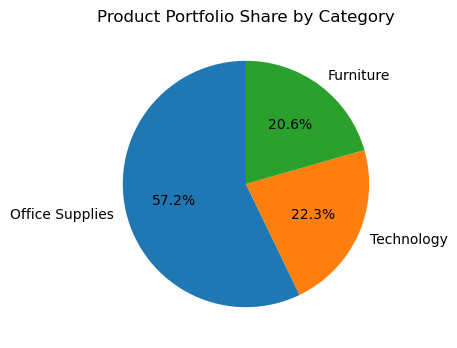

In [39]:
# Product portfolio share by category
unique_products_per_category = (
    sales_df
        .groupby('Category')['Product Name']
        .nunique()
        .reset_index(name='Unique_Product_Count')
        .sort_values('Unique_Product_Count', ascending=False)
)

# Visualize the product portfolio share by category
plt.figure(figsize=(5, 4))

plt.pie(
    unique_products_per_category['Unique_Product_Count'],
    labels=unique_products_per_category['Category'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Product Portfolio Share by Category')


print('Unique products per category:')
print(unique_products_per_category)
#plt.savefig("product_portfolio_share_by_category.jpg", dpi=300)
plt.show()

          Category  Total Revenue  Revenue Share (%)
0  Office Supplies    705422.3340          31.192167
1        Furniture    728658.5757          32.219621
2       Technology    827455.8730          36.588212


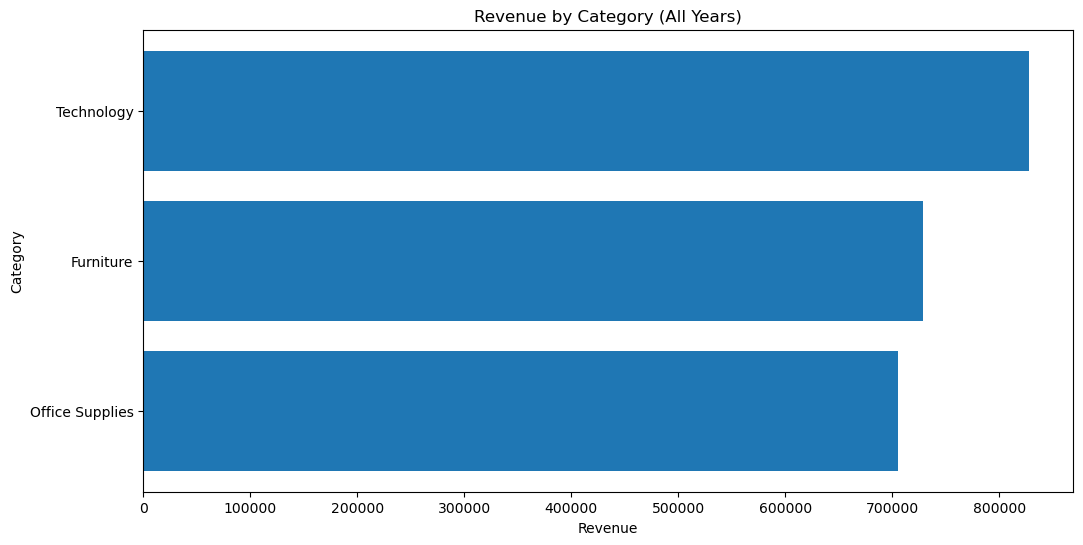

In [35]:
# Revenue share by category with year filter

# Select year (set to None if you want all years)
year = None

sales_df_year = sales_df.copy()

if year is not None:
    sales_df_year = sales_df_year[
        sales_df_year['Order Date'].dt.year == year
    ]

category_sales = (
    sales_df_year
        .groupby('Category')['Sales']
        .sum()
        .sort_values(ascending=True)
)

category_sales_df = category_sales.reset_index()
category_sales_df.columns = ['Category', 'Total Revenue']

total_revenue = category_sales_df['Total Revenue'].sum()

category_sales_df['Revenue Share (%)'] = (
    category_sales_df['Total Revenue'] / total_revenue * 100
)

print(category_sales_df)

# Visualize the revenue ranking by sub-category
plt.figure(figsize=(12, 6))
plt.barh(
    category_sales_df['Category'],
    category_sales_df['Total Revenue']
)

title_year = year if year else "All Years"

plt.title(f'Revenue by Category ({title_year})')
plt.xlabel('Revenue')
plt.ylabel('Category')
#plt.savefig("revenue_by_category.jpg", dpi=300)
plt.show()

## <u>Sub-Category Analysis<u/>

In [69]:
# Amount of subcategories per category
subcategory_count = (
    sales_df
        .groupby('Category')['Sub-Category']
        .nunique()
        .reset_index(name='Subcategory_Count')
        .sort_values('Subcategory_Count', ascending=False)
)

print(subcategory_count)

          Category  Subcategory_Count
1  Office Supplies                  9
0        Furniture                  4
2       Technology                  4


In [50]:
# Amount of products per subcategory
unique_products_per_subcategory = (
    sales_df
        .groupby(['Category', 'Sub-Category'])['Product Name']
        .nunique()
        .reset_index(name='Unique_Product_Count')
        .sort_values(['Category', 'Unique_Product_Count'], ascending=[True, False])
)

print('Unique products per category and sub-category:')
print(unique_products_per_subcategory)

Unique products per category and sub-category:
           Category Sub-Category  Unique_Product_Count
2         Furniture  Furnishings                   186
1         Furniture       Chairs                    88
3         Furniture       Tables                    56
0         Furniture    Bookcases                    50
10  Office Supplies        Paper                   277
6   Office Supplies      Binders                   211
5   Office Supplies          Art                   157
11  Office Supplies      Storage                   131
4   Office Supplies   Appliances                    97
9   Office Supplies       Labels                    70
7   Office Supplies    Envelopes                    44
12  Office Supplies     Supplies                    36
8   Office Supplies    Fasteners                    34
16       Technology       Phones                   189
13       Technology  Accessories                   147
15       Technology     Machines                    63
14       Technolog

  Sub-Category  Total Revenue  Revenue Share (%)
0    Fasteners       3001.960           0.425555
1       Labels      12347.726           1.750402
2    Envelopes      16128.046           2.286296
3          Art      26705.410           3.785734
4     Supplies      46420.308           6.580499
5        Paper      76828.304          10.891107
6   Appliances     104618.403          14.830605
7      Binders     200028.785          28.355891
8      Storage     219343.392          31.093911


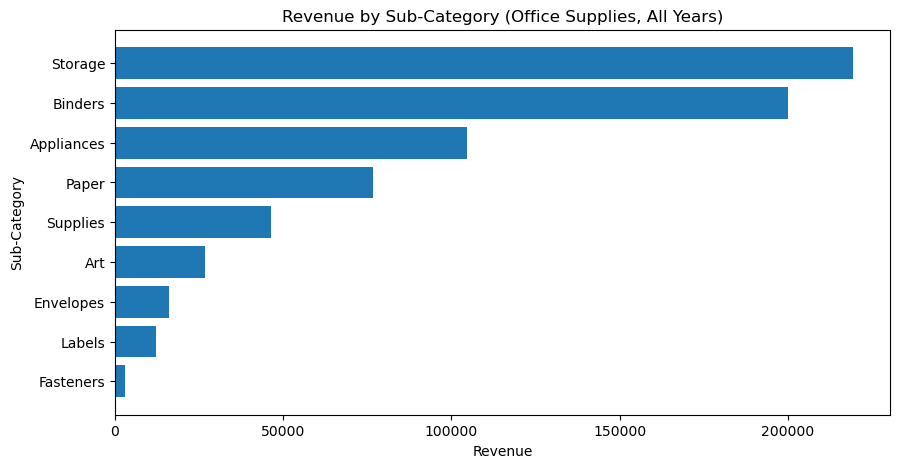

In [61]:
# Revenue share by sub-category per category

# Filters (set to None if you don't want to filter)
year = None
selected_category = 'Office Supplies'   # Furniture, Office Supplies, Technology

sales_df_filtered = sales_df.copy()

sales_df_filtered['Order Date'] = pd.to_datetime(sales_df_filtered['Order Date'])

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_category is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Category'] == selected_category
    ]

subcategory_sales = (
    sales_df_filtered
        .groupby('Sub-Category')['Sales']
        .sum()
        .sort_values(ascending=True)
)

subcategory_sales_df = subcategory_sales.reset_index()
subcategory_sales_df.columns = ['Sub-Category', 'Total Revenue']

total_revenue = subcategory_sales_df['Total Revenue'].sum()

subcategory_sales_df['Revenue Share (%)'] = (
    subcategory_sales_df['Total Revenue'] / total_revenue * 100
)

print(subcategory_sales_df)

# Visualize the revenue ranking by sub-category
plt.figure(figsize=(10,5))
plt.barh(
    subcategory_sales.index,
    subcategory_sales.values
)

title_category = selected_category if selected_category else "All Categories"
title_year = year if year else "All Years"

plt.title(f'Revenue by Sub-Category ({title_category}, {title_year})')
plt.xlabel('Revenue')
plt.ylabel('Sub-Category')
#plt.savefig("revenue_per_category_officesupplies.jpg", dpi=300)
plt.show()

# **CUSTOMER INSIGHTS**

In [13]:
# Number of customers by ID
year = 2018
if year is not None:
    filtered_df = sales_df[sales_df['Order Date'].dt.year == year]
else:
    filtered_df = sales_df

number_of_customers = filtered_df['Customer ID'].nunique()
print(number_of_customers)

690


In [297]:
# Number of customers by Name (checking for duplicates)
number_of_customers = sales_df['Customer Name'].nunique()

print(number_of_customers)

793


In [20]:
# Customers appearing in more than one region
customer_region_count = (
    sales_df
        .groupby('Customer ID')['Region']
        .nunique()
)

multi_state_customers = customer_region_count[customer_region_count > 1]

print("Number of customers in multiple regions:", len(multi_state_customers))

Customers in multiple regions: 765


In [18]:
# Customers appearing in more than one state
customer_state_count = (
    sales_df
        .groupby('Customer ID')['State']
        .nunique()
)

multi_state_customers = customer_state_count[customer_state_count > 1]

print("Number of customers in multiple states:", len(multi_state_customers))

Customers in multiple states: 777


In [12]:
# Customers appearing in more than one city
customer_city_count = (
    sales_df
        .groupby('Customer ID')['City']
        .nunique()
)

multi_city_customers = customer_city_count[customer_city_count > 1]

print("Number of customers in multiple cities:", len(multi_city_customers))

Customers in multiple cities: 779


In [7]:
# Number of unique customers per region

# Define year (set to None to include all years)
year = 2015

if year is not None:
    filtered_df = sales_df[sales_df['Order Date'].dt.year == year]
else:
    filtered_df = sales_df

region = (
    filtered_df
        .groupby('Region')['Customer ID']
        .nunique()
        .reset_index(name='Number of Customers')
)

total_unique_customers = filtered_df['Customer ID'].nunique()

region['Share of Total Unique Customers (%)'] = (
    region['Number of Customers'] / total_unique_customers * 100
).round(2)

title_year = year if year else "all years"

print(f'Number of unique customers per region during {title_year}:')
print(region)

Number of unique customers per region during 2015:
    Region  Number of Customers  Share of Total Unique Customers (%)
0  Central                  200                                33.96
1     East                  225                                38.20
2    South                  152                                25.81
3     West                  266                                45.16


In [14]:
# Number of states with customers
number_of_states = sales_df['State'].nunique()

print("There are customers in", number_of_states, "states")

There are customers in 49 states


In [49]:
# Number of customers per state

# Filters (set to None if you don't want to filter)
year = None
selected_region = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

state = (
    sales_df_filtered
        .groupby('State')['Customer ID']
        .nunique()
        .reset_index(name='Number of Customers')
        .sort_values(by='Number of Customers', ascending=False)
)

total_unique_customers = sales_df_filtered['Customer ID'].nunique()

state['Share of Total Unique Customers (%)'] = (
    state['Number of Customers'] / total_unique_customers * 100
).round(2)

title_year = year if year else "all years"
title_region = (f" in the {selected_region} region" if selected_region is not None else "")

print(f'Number of unique customers per city {title_region} during {title_year}:')
print(state.head(20))

This is the number of unique customers per city  during all years:
             State  Number of Customers  Share of Total Unique Customers (%)
3       California                  570                                71.88
30        New York                  409                                51.58
41           Texas                  367                                46.28
36    Pennsylvania                  255                                32.16
11        Illinois                  231                                29.13
45      Washington                  223                                28.12
33            Ohio                  196                                24.72
8          Florida                  178                                22.45
31  North Carolina                  120                                15.13
44        Virginia                  107                                13.49
20        Michigan                  105                                13.24
1        

In [51]:
# Number of unique customers per city by region and/or state

# Filters (set to None if you don't want to filter)
year = None
selected_region = None
selected_state = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

city = (
    sales_df_filtered
        .groupby('City')['Customer ID']
        .nunique()
        .reset_index(name='Number of Customers')
        .sort_values(by='Number of Customers', ascending=False)
)

total_unique_customers = sales_df_filtered['Customer ID'].nunique()

city['Share of Total Unique Customers (%)'] = (
    city['Number of Customers'] / total_unique_customers * 100
).round(2)

title_year = year if year else "all years"
title_region = (f" in the {selected_region} region" if selected_region is not None else "")
title_state = (f" in the state of {selected_state}" if selected_state is not None else "")

print(f'Number of unique customers per city {title_region}{title_state} during {title_year}:')
print(city.head(10))

This is the number of unique customers per city  during all years:
              City  Number of Customers  Share of Total Unique Customers (%)
327  New York City                  349                                44.01
265    Los Angeles                  300                                37.83
372   Philadelphia                  237                                29.89
436  San Francisco                  230                                29.00
450        Seattle                  187                                23.58
207        Houston                  170                                21.44
80         Chicago                  150                                18.92
94        Columbus                   96                                12.11
435      San Diego                   86                                10.84
109         Dallas                   77                                 9.71


## <u>Customer Segmentation<u/>

In [300]:
# Types of customers

types_of_customers = sales_df['Segment'].unique()
print(types_of_customers)

['Consumer' 'Corporate' 'Home Office']


       Segment  Number of Customers  Share of Total (%)
0     Consumer                  307               52.12
1    Corporate                  177               30.05
2  Home Office                  105               17.83


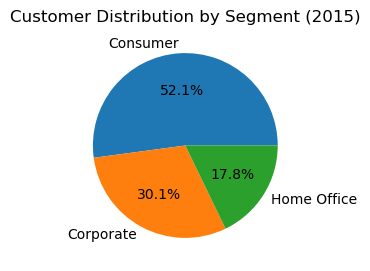

In [9]:
# Number of customers in each segment

# Filters (set to None if you don't want to filter)
year = 2015
selected_region = None
selected_state = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

number_of_customers = (
    sales_df_filtered
        .groupby('Segment')['Customer ID']
        .nunique()
        .reset_index(name='Number of Customers')
        .sort_values(by='Number of Customers', ascending=False)
)

total_customers = sales_df_filtered['Customer ID'].nunique()

number_of_customers['Share of Total (%)'] = (
    number_of_customers['Number of Customers'] / total_customers * 100
).round(2)


title_year = year if year else "all years"
title_region = (f", {selected_region} region" if selected_region is not None else "")
title_state = (f", in the state of {selected_state}." if selected_state is not None else "")

plt.figure(figsize=(4, 3))

plt.pie(
    number_of_customers['Number of Customers'],
    labels=number_of_customers['Segment'],
    autopct='%1.1f%%'
)

plt.title(f'Customer Distribution by Segment ({title_year}{title_region}{title_state})')

print(number_of_customers)
#plt.savefig("customer_segment_share.jpg", dpi=300)
plt.show()

       Segment  Total Revenue  Revenue Share (%)
0     Consumer     1148060.53              50.76
1    Corporate      688494.07              30.44
2  Home Office      424982.18              18.79


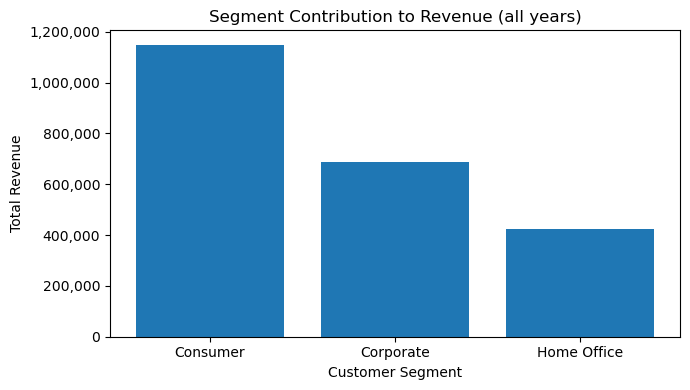

In [51]:
year = None
selected_region = None
selected_state = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

segment_revenue = (
    sales_df_filtered
        .groupby('Segment')['Sales']
        .sum()
        .reset_index(name='Total Revenue')
        .sort_values(by='Total Revenue', ascending=False)
)

total_revenue = sales_df_filtered['Sales'].sum()

segment_revenue['Revenue Share (%)'] = (
    segment_revenue['Total Revenue'] / total_revenue * 100
).round(2)

segment_revenue['Total Revenue'] = segment_revenue['Total Revenue'].round(2)

title_year = year if year else "all years"
title_region = (f", {selected_region} region" if selected_region is not None else "")
title_state = (f", in the state of {selected_state}" if selected_state is not None else "")

plt.figure(figsize=(7, 4))

plt.bar(
    segment_revenue['Segment'],
    segment_revenue['Total Revenue']
)

plt.title(f'Segment Contribution to Revenue ({title_year}{title_region}{title_state})')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')

plt.ticklabel_format(style='plain', axis='y')

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.tight_layout()

print(segment_revenue)
#plt.savefig("customer_segment_revenue_contribution.jpg", dpi=300)
plt.show()

       Segment  Number of Orders  Order Share (%)
0     Consumer              2537            51.54
1    Corporate              1491            30.29
2  Home Office               894            18.16


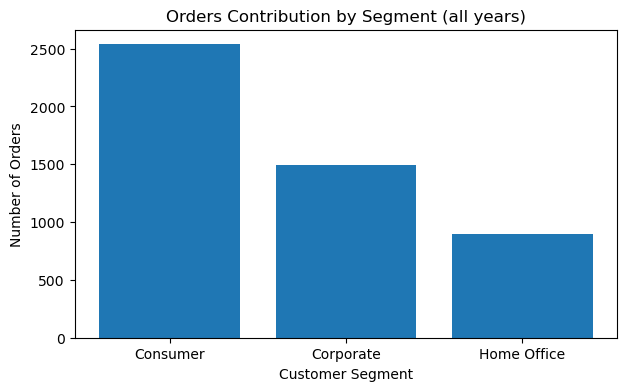

In [59]:
# Segments contribution to order volume

# Filters (set to None if you don't want to filter)
year = None
selected_region = None
selected_state = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

segment_orders = (
    sales_df_filtered
        .groupby('Segment')['Order ID']
        .nunique()
        .reset_index(name='Number of Orders')
        .sort_values(by='Number of Orders', ascending=False)
)

total_orders = sales_df_filtered['Order ID'].nunique()

segment_orders['Order Share (%)'] = (
    segment_orders['Number of Orders'] / total_orders * 100
).round(2)

# Visualization
plt.figure(figsize=(7, 4))

plt.bar(
    segment_orders['Segment'],
    segment_orders['Number of Orders']
)

title_year = year if year else "all years"
title_region = (f", {selected_region} region" if selected_region is not None else "")
title_state = (f", in the state of {selected_state}" if selected_state is not None else "")

print(segment_orders)
plt.title(f'Orders Contribution by Segment ({title_year}{title_region}{title_state})')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')

#plt.savefig("customer_segment_order_volume_contribution.jpg", dpi=300)
plt.show()

       Segment  Average Order Value
2  Home Office               475.37
1    Corporate               461.77
0     Consumer               452.53


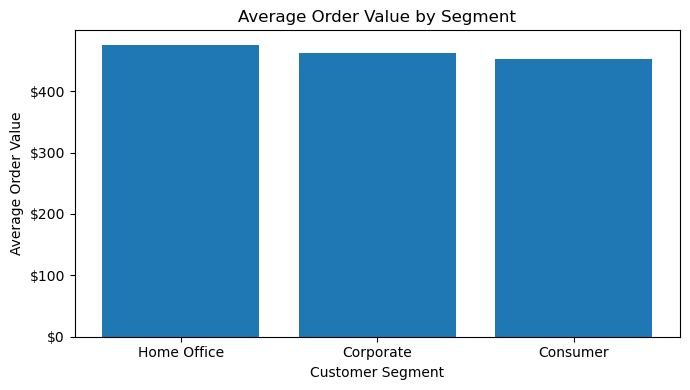

In [61]:
# AOV (Average Order Value) per Segment

# Filters (set to None if you don't want to filter)
year = None
selected_region = None
selected_state = None

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

segment_revenue = (
    sales_df_filtered
        .groupby('Segment')['Sales']
        .sum()
)

segment_orders = (
    sales_df_filtered
        .groupby('Segment')['Order ID']
        .nunique()
)

avg_order_value = (
    (segment_revenue / segment_orders)
        .reset_index(name='Average Order Value')
        .sort_values(by='Average Order Value', ascending=False)
)

avg_order_value['Average Order Value'] = avg_order_value['Average Order Value'].round(2)


# Visualization
plt.figure(figsize=(7, 4))

plt.bar(
    avg_order_value['Segment'],
    avg_order_value['Average Order Value']
)

plt.title('Average Order Value by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Order Value')

plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f'${x:,.0f}')
)

plt.tight_layout()

print(avg_order_value)
plt.show()

## <u>Customer Loyalty<u/>

In [77]:
# Most repeating buyers and their contribution to revenue and order volume

# Filters (set to None if you don't want to filter)
year = 2015
selected_region = 'West'
selected_state = None
selected_segment = None

sales_df['Order Date'] = pd.to_datetime(sales_df['Order Date'])

sales_df_filtered = sales_df.copy()

if year is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Order Date'].dt.year == year
    ]

if selected_region is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Region'] == selected_region
    ]

if selected_state is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['State'] == selected_state
    ]

if selected_segment is not None:
    sales_df_filtered = sales_df_filtered[
        sales_df_filtered['Segment'] == selected_segment
    ]

total_revenue = sales_df_filtered['Sales'].sum()

customer_loyalty = (
    sales_df_filtered
        .groupby(['Customer ID', 'Customer Name'])
        .agg(
            Purchases=('Order ID', 'nunique'),
            Total_Revenue=('Sales', 'sum')
        )
        .reset_index()
)

customer_loyalty['Revenue Share (%)'] = (
    customer_loyalty['Total_Revenue'] / total_revenue * 100
).round(2)

customer_loyalty = customer_loyalty.sort_values(
    by=['Purchases', 'Total_Revenue'],
    ascending=False
)

customer_loyalty = customer_loyalty.sort_values(
    by='Purchases',
    ascending=False
)

print(customer_loyalty.head(10))

    Customer ID   Customer Name  Purchases  Total_Revenue  Revenue Share (%)
14     AI-10855  Arianne Irving          3       2290.458               1.57
190    NM-18445    Nathan Mautz          3        563.022               0.39
227    SE-20110    Sanjit Engle          3        270.730               0.19
16     AP-10915  Arthur Prichep          3       1535.804               1.05
198    PB-19150    Philip Brown          2        206.152               0.14
73     DW-13195    David Wiener          2        423.560               0.29
254    TS-21340   Toby Swindell          2        387.202               0.27
9      AH-10030   Aaron Hawkins          2        336.864               0.23
70     DP-13390   Dennis Pardue          2        256.600               0.18
124    JF-15490    Jeremy Farry          2        256.560               0.18
